# Python Assignment 14 - 29/01/2025

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv("Car_sales (1)_336060.csv")
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Manufacturer        157 non-null    object 
 1   Model               157 non-null    object 
 2   Sales_in_thousands  157 non-null    float64
 3   resale_value        121 non-null    float64
 4   Vehicle_type        157 non-null    object 
 5   Price_in_thousands  155 non-null    float64
 6   Engine_size         156 non-null    float64
 7   Horsepower          156 non-null    float64
 8   Wheelbase           156 non-null    float64
 9   Width               156 non-null    float64
 10  Length              156 non-null    float64
 11  Kerb_weight         155 non-null    float64
 12  Fuel_capacity       156 non-null    float64
 13  Fuel_efficiency     154 non-null    float64
 14  Latest_Launch       157 non-null    object 
 15  Power_perf_factor   155 non-null    float64
dtypes: float

,Manufacturer,Model,Sales_in_thousands,resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Kerb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639


#### Column Descriptions: 
1. Manufacturer: Brand of the vehicle (e.g., Acura, BMW).
2. Model: Specific name of the car (e.g., Integra, Corolla).
3. Sales_in_thousands: Total sales volume (in thousands of units).
4. resale_value: Estimated resale value (in thousands of USD).
5. Vehicle_type: Type of vehicle (e.g., Passenger, Car).
6. Price_in_thousands: Retail price (in thousands of USD).
7. Engine_size: Engine displacement (in liters).
8. Horsepower: Engine power (HP).
9. Wheelbase: Distance between front and rear wheels (inches).
10. Width: Vehicle width (inches).
11. Length: Vehicle length (inches).
12. Kerb_weight: Vehicle weight (pounds).
13. Fuel_capacity: Fuel tank capacity (gallons).
14. Fuel_efficiency: Miles per gallon (MPG).
15. Latest_Launch: Release date of the model.
16. Power_perf_factor: Performance score (higher = better).

### 1. Preliminary data cleaning (checking for duplicate entries/ missing entries/ incorrectly listed entries etc.)

In [3]:
#Check for duplicate entries
print("Duplicate entries:", data.duplicated().sum())
#Check for missing values
print("Missing values:\n", data.isnull().sum())
#Check for incorrectly listed entries 
print("Negative values in numerical columns:\n", data.select_dtypes(include=[np.number]).lt(0).sum())
#Drop rows with critical missing values 
data = data.dropna(subset=["Price_in_thousands", "Power_perf_factor"])
#Impute missing numerical values with median
numerical_cols = data.select_dtypes(include=[np.number]).columns
data[numerical_cols] = data[numerical_cols].fillna(data[numerical_cols].median())
#Convert Latest_Launch to datetime
data["Latest_Launch"] = pd.to_datetime(data["Latest_Launch"], format="mixed")

print("Cleaned data:\n", data.head())

Duplicate entries: 0
Missing values:
 Manufacturer           0
Model                  0
Sales_in_thousands     0
resale_value          36
Vehicle_type           0
Price_in_thousands     2
Engine_size            1
Horsepower             1
Wheelbase              1
Width                  1
Length                 1
Kerb_weight            2
Fuel_capacity          1
Fuel_efficiency        3
Latest_Launch          0
Power_perf_factor      2
dtype: int64
Negative values in numerical columns:
 Sales_in_thousands    0
resale_value          0
Price_in_thousands    0
Engine_size           0
Horsepower            0
Wheelbase             0
Width                 0
Length                0
Kerb_weight           0
Fuel_capacity         0
Fuel_efficiency       0
Power_perf_factor     0
dtype: int64
Cleaned data:
   Manufacturer    Model  Sales_in_thousands  resale_value Vehicle_type  \
0        Acura  Integra              16.919        16.360    Passenger   
1        Acura       TL              39.384   

### 2. Understanding the nature of the data (through statistical analyses), Exploratory Data Analytics (using visualizations such as graphs and interactive plots)

In [9]:
#Descriptive statistics
print("Descriptive statistics:")
data.describe()

Descriptive statistics:


,Sales_in_thousands,resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Kerb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155,155.000000
mean,53.245832,17.118871,27.390755,3.060000,185.696774,107.490968,71.153548,187.313548,3.377194,17.956774,23.832258,2011-12-04 11:55:21.290322688,77.043591
min,0.110000,5.160000,9.235000,1.000000,55.000000,92.600000,62.600000,149.400000,1.895000,10.300000,15.000000,2008-02-13 00:00:00,23.276272
25%,14.074500,12.510000,18.017500,2.300000,149.000000,103.000000,68.400000,177.550000,2.971000,15.800000,21.000000,2011-07-02 12:00:00,60.407707
50%,29.450000,14.010000,22.799000,3.000000,175.000000,107.000000,70.500000,187.800000,3.341000,17.200000,24.000000,2011-12-10 00:00:00,72.030917
75%,68.183500,17.807500,31.947500,3.650000,215.000000,112.200000,73.450000,196.150000,3.799500,19.650000,26.000000,2012-06-03 00:00:00,89.414878
max,540.561000,67.550000,85.500000,8.000000,450.000000,138.700000,79.900000,224.500000,5.572000,32.000000,45.000000,2012-12-29 00:00:00,188.144323
std,68.397550,10.254111,14.351653,1.047979,56.796444,7.665925,3.462776,13.470034,0.630465,3.900050,4.265262,NaN,25.142664


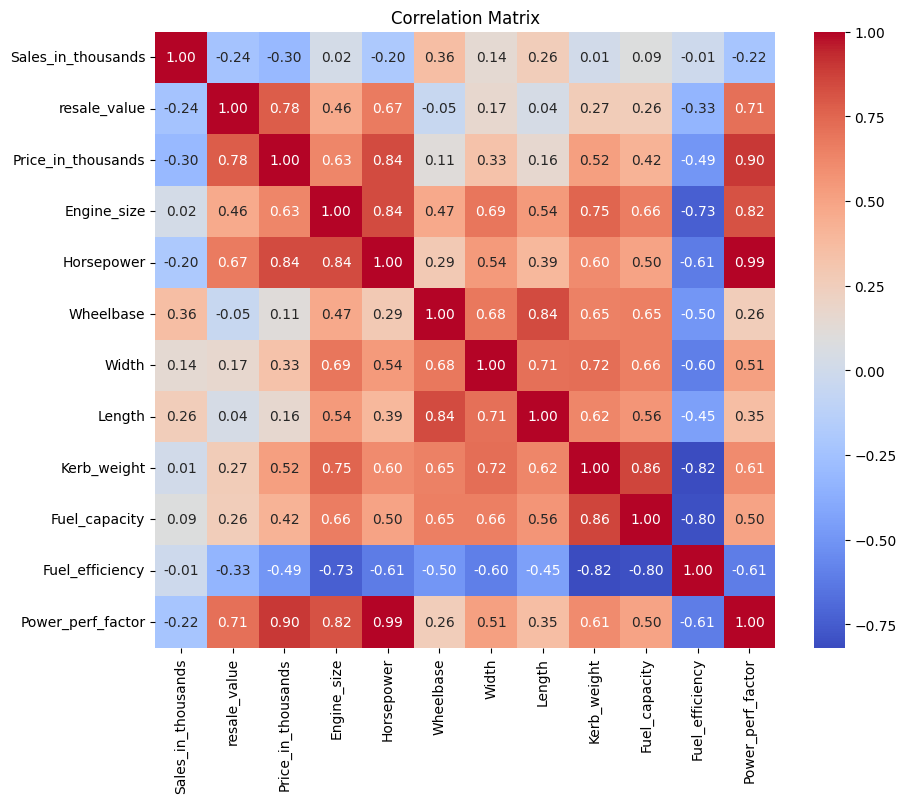

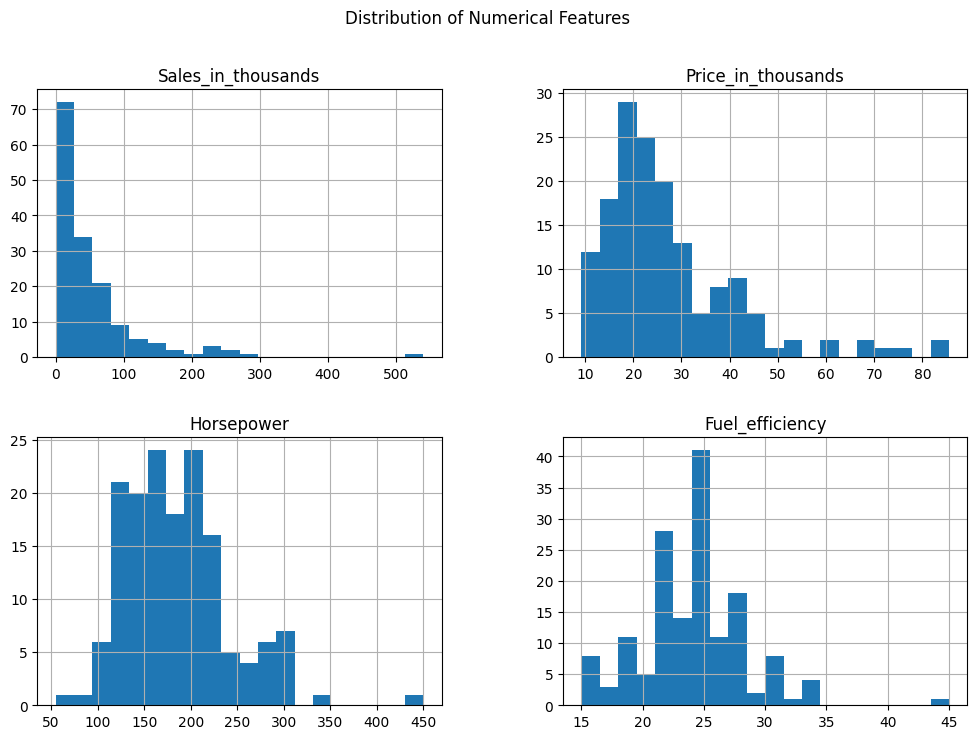

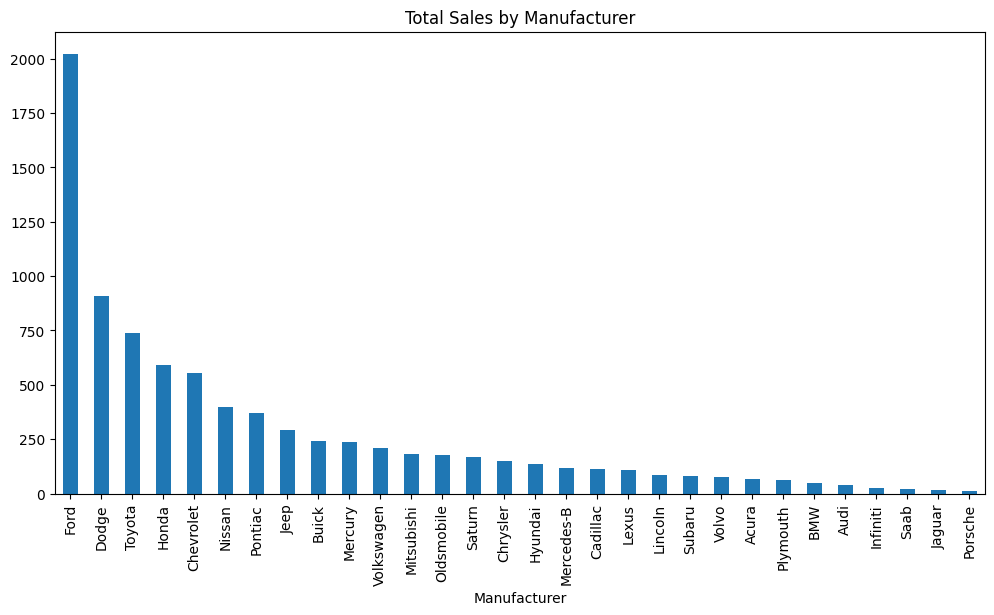

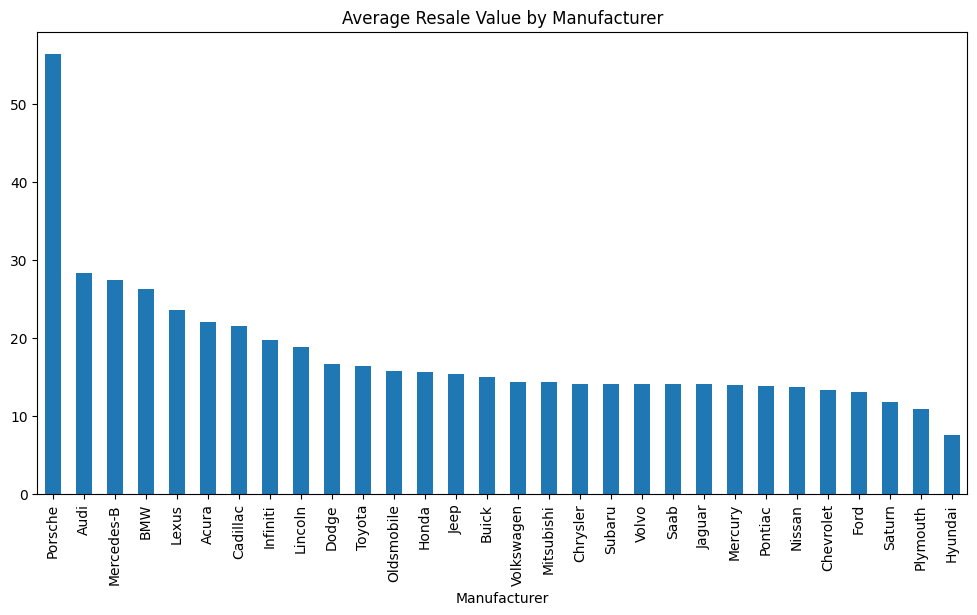

In [8]:
#only numeric columns for correlation matrix
numeric_data = data.select_dtypes(include=[np.number])
# Compute correlation matrix
corr_matrix = numeric_data.corr()
# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

#Distribution of numerical features
numerical_cols = ["Sales_in_thousands", "Price_in_thousands", "Horsepower", "Fuel_efficiency"]
data[numerical_cols].hist(bins=20, figsize=(12, 8))
plt.suptitle("Distribution of Numerical Features")
plt.show()

#Sales by Manufacturer
sales_by_manufacturer = data.groupby("Manufacturer")["Sales_in_thousands"].sum().sort_values(ascending=False)
sales_by_manufacturer.plot(kind="bar", figsize=(12, 6), title="Total Sales by Manufacturer")
plt.show()

#Resale value by Manufacturer
resale_by_manufacturer = data.groupby("Manufacturer")["resale_value"].mean().sort_values(ascending=False)
resale_by_manufacturer.plot(kind="bar", figsize=(12, 6), title="Average Resale Value by Manufacturer")
plt.show()

#### Insights:
1. Correlation: 
    1. Higher price strongly correlates with better performance, larger engines, and higher resale value.
    2. Fuel efficiency is negatively correlated with these factors.
    3. Sales have a weak negative relationship with price and performance, indicating other factors significantly influence sales.
    4. Heavier cars tend to have larger engines and fuel tanks.
    5. Wider cars are often longer.
2. A few car models dominate sales, while most sell much less.
3. Prices are mostly in the lower-mid range, but some are very high.
4. Horsepower is fairly evenly distributed.
5. Fuel efficiency clusters on the higher end, with fewer gas-guzzlers.
6. Average Resale Value:
    1. Porsche has the highest average resale value, significantly outpacing all other manufacturers.
    2. Luxury brands (Audi, Mercedes-Benz, BMW, Lexus, Acura) generally hold higher resale values.
    3. Domestic and more mainstream brands (Ford, Chevrolet, Nissan, etc.) tend to have lower average resale values, with Plymouth and Hyundai at the bottom.
    4. This suggests brand perception, build quality, and long-term reliability influence resale value.
7. Total Sales:
    1. Ford dominates total sales, significantly exceeding all other manufacturers.
    2. Dodge, Toyota, and Honda follow as distant contenders.
    3. Most other brands have considerably lower total sales, forming a long tail.
    4. Luxury brands like Porsche, Jaguar, Infiniti, Audi, and BMW have the lowest total sales.
    5. This indicates a mass-market focus on a few key brands, with niche markets for luxury or specialized vehicles.

### 3. Can the manufacturer figure out where the market is headed in terms of car sales and predict which kind of car (based on the features provided in the dataset) they should invest in to maximize sales? Is there some change they should bring about to existing cars to improve sales? Should they cut down on some models to optimize their sales?

In [33]:
# Group by Vehicle_type and analyze sales
sales_by_type = data.groupby("Vehicle_type")["Sales_in_thousands"].sum().sort_values(ascending=False)
print("Sales by Vehicle Type:\n", sales_by_type)

# Analyze features of top-selling models
top_selling_models = data.nlargest(10, "Sales_in_thousands")
print("Top 10 Selling Models:\n", (top_selling_models[["Manufacturer", "Model", "Sales_in_thousands", "Price_in_thousands", "Horsepower", "Fuel_efficiency"]]))

Sales by Vehicle Type:
 Vehicle_type
Passenger    5001.070
Car          3252.034
Name: Sales_in_thousands, dtype: float64
Top 10 Selling Models:
     Manufacturer       Model  Sales_in_thousands  Price_in_thousands  \
56          Ford    F-Series             540.561              26.935   
52          Ford    Explorer             276.747              31.930   
137       Toyota       Camry             247.994              17.518   
49          Ford      Taurus             245.815              17.885   
58         Honda      Accord             230.902              15.350   
40         Dodge  Ram Pickup             227.061              19.460   
55          Ford      Ranger             220.650              12.050   
57         Honda       Civic             199.685              12.885   
45         Dodge     Caravan             181.749              19.565   
50          Ford       Focus             175.670              12.315   

     Horsepower  Fuel_efficiency  
56        220.0           

In [18]:
# Analyze features of least-selling models
least_selling_models = data.nsmallest(10, "Sales_in_thousands")
print("Least 10 Selling Models:\n", least_selling_models[["Manufacturer", "Model", "Sales_in_thousands", "Price_in_thousands", "Horsepower", "Fuel_efficiency"]])

Least 10 Selling Models:
     Manufacturer           Model  Sales_in_thousands  Price_in_thousands  \
83    Mitsubishi          3000GT               0.110              25.450   
39         Dodge           Viper               0.916              69.725   
99    Mercedes-B           CL500               0.954              85.500   
108   Oldsmobile         Cutlass               1.112              18.145   
125      Porsche   Carrera Coupe               1.280              71.020   
6           Audi              A8               1.380              62.000   
97    Mercedes-B          SLK230               1.526              41.000   
126      Porsche  Carrera Cabrio               1.866              74.970   
117     Plymouth         Prowler               1.872              43.000   
95    Mercedes-B        SL-Class               3.311              82.600   

     Horsepower  Fuel_efficiency  
83        161.0             21.0  
39        450.0             16.0  
99        302.0             20.0

#### Insights:
1. Ford is the undisputed sales leader, dwarfing all other manufacturers.
2. Dodge, Toyota, and Honda occupy a second tier of strong performance, though significantly behind Ford.
3. Invest in vehicles with balanced performance and fuel efficiency mainly Ford F-Series, Ford Explorer, Toyota Camry, Ford Taurus, Honda Accord, Dodge Ram Pickup.
4. Volkswagen, Mitsubishi, Oldsmobile, Saturn, Chrysler, and Hyundai represent a group with lower sales figures.
5. Should cut down some models mainly Mitsubishi 3000GT, Dogde Viper, Mercedes-B CL500, Oldsmobile Cutlass, Porshe Carrera Coupe.

### 4. Can you categorize the cars into different price segments and advise your friend on which car to buy if they want a high resale value in the different segments? Or create a consumer guideline for the least expensive car based on a set of desired features?

In [19]:
# Categorize cars into price segments
bins = [0, 20, 40, 60, 100]
labels = ["Budget", "Mid-Range", "Premium", "Luxury"]
data["Price_Segment"] = pd.cut(data["Price_in_thousands"], bins=bins, labels=labels)

# Analyze resale value by price segment
resale_by_segment = data.groupby("Price_Segment")["resale_value"].mean().sort_values(ascending=False)
print("Average Resale Value by Price Segment:\n", resale_by_segment)

# Recommend cars with high resale value in each segment
high_resale_cars = data.loc[data.groupby("Price_Segment")["resale_value"].idxmax()]
print("Cars with Highest Resale Value in Each Segment:\n", high_resale_cars[["Manufacturer", "Model", "Price_Segment", "resale_value"]])

# Consumer guideline for budget cars
budget_cars = data[data["Price_Segment"] == "Budget"]
best_budget_cars = budget_cars.sort_values(by=["Fuel_efficiency", "resale_value"], ascending=[False, False])
print("Best Budget Cars:\n", best_budget_cars[["Manufacturer", "Model", "Price_in_thousands", "Fuel_efficiency", "resale_value"]].head())

Average Resale Value by Price Segment:
 Price_Segment
Luxury       45.330000
Premium      24.000625
Mid-Range    16.999539
Budget       11.178364
Name: resale_value, dtype: float64
Cars with Highest Resale Value in Each Segment:
     Manufacturer           Model Price_Segment  resale_value
148   Volkswagen          Cabrio        Budget        16.575
9            BMW            528i     Mid-Range        36.125
93    Mercedes-B         E-Class       Premium        41.450
126      Porsche  Carrera Cabrio        Luxury        67.550
Best Budget Cars:
     Manufacturer    Model  Price_in_thousands  Fuel_efficiency  resale_value
26     Chevrolet    Metro               9.235             45.0         5.160
130       Saturn       SC              12.535             33.0        10.590
136       Toyota  Corolla              13.108             33.0        10.025
129       Saturn       SL              10.685             33.0         9.200
25     Chevrolet    Prizm              13.960             33.

C:\Users\himan\AppData\Local\Temp\ipykernel_11188\4244204130.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resale_by_segment = data.groupby("Price_Segment")["resale_value"].mean().sort_values(ascending=False)
C:\Users\himan\AppData\Local\Temp\ipykernel_11188\4244204130.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  high_resale_cars = data.loc[data.groupby("Price_Segment")["resale_value"].idxmax()]


#### Insights:
1. Luxury cars command the highest average resale value, reflecting their premium features, brand prestige, and initial high cost.
2. Porsche Carrera Cabrio boasts the highest resale value among luxury cars.
3. Premium cars have the second-highest average resale value, offering a balance of luxury and relatively lower depreciation.
4. Mercedes-Benz E-Class tops the premium segment for resale value.
5. Mid-range cars maintain a respectable average resale value, making them a practical choice for many buyers.
6. BMW 528i leads the mid-range segment in resale value.
7. Budget cars experience the most significant depreciation, with the lowest average resale value. This is typical due to their focus on affordability over long-term value retention.
8. Volkswagen Cabrio stands out with a relatively high resale value in the budget segment.
9. Chevrolet Metro, Saturn SC, Toyota Corolla, Saturn SL, and Chevrolet Prizm are highlighted as good budget options. These cars likely balance low purchase price, good fuel efficiency, and acceptable resale value within the budget segment.

### 5. What is the relationship between sales and other features? Which manufacturers and models have the highest and lowest sales? How does this vary according to different clusters? What could be the underlying reasons for this?

Correlation between Sales and features:
 Sales_in_thousands    1.000000
Wheelbase             0.358279
Length                0.256633
Width                 0.140489
Fuel_capacity         0.085925
Engine_size           0.020499
Kerb_weight           0.009379
Fuel_efficiency      -0.014831
Horsepower           -0.195716
Power_perf_factor    -0.223252
resale_value         -0.237200
Price_in_thousands   -0.304734
Name: Sales_in_thousands, dtype: float64


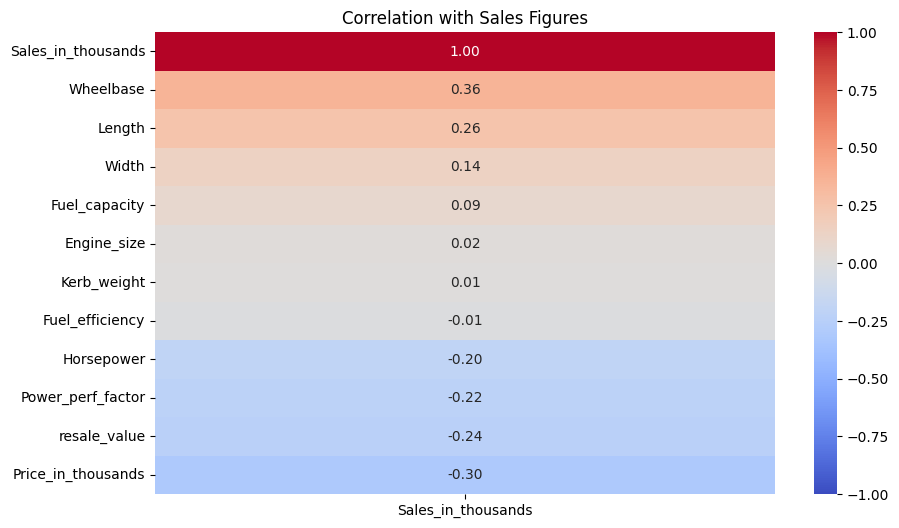

Top 5 Manufacturers by Sales:
 Manufacturer
Ford         2022.635
Dodge         910.149
Toyota        740.205
Honda         592.674
Chevrolet     554.365
Name: Sales_in_thousands, dtype: float64
Botton 5 Manufacturers by Sales:
 Manufacturer
Porsche     12.128
Jaguar      15.467
Saab        21.306
Infiniti    23.713
Audi        40.557
Name: Sales_in_thousands, dtype: float64
Top 5 Models by Sales:
 Manufacturer  Model   
Ford          F-Series    540.561
              Explorer    276.747
Toyota        Camry       247.994
Ford          Taurus      245.815
Honda         Accord      230.902
Name: Sales_in_thousands, dtype: float64
Botton 5 Models by Sales:
 Manufacturer  Model        
Mitsubishi    3000GT           0.110
Dodge         Viper            0.916
Mercedes-B    CL500            0.954
Oldsmobile    Cutlass          1.112
Porsche       Carrera Coupe    1.280
Name: Sales_in_thousands, dtype: float64


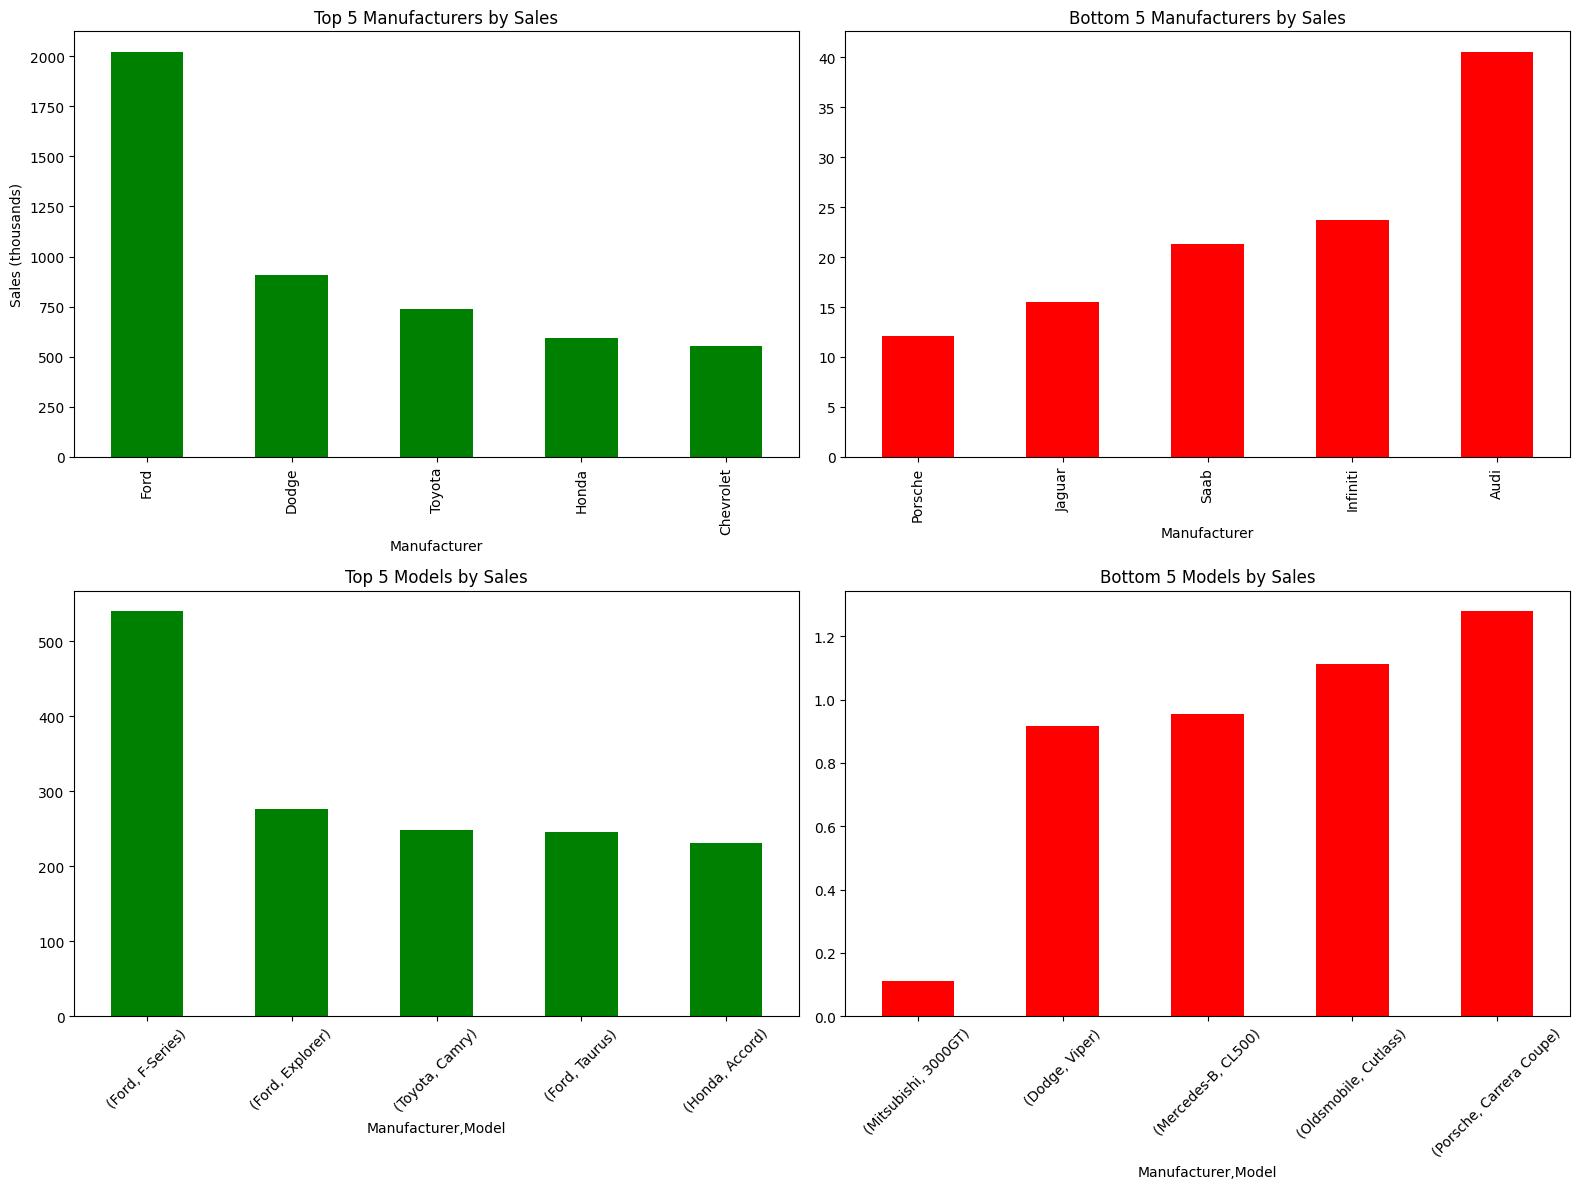

Sales Distribution by Vehicle Type:
 Vehicle_type
Car          3252.034
Passenger    5001.070
Name: Sales_in_thousands, dtype: float64
Sales Distribution by Price Segment:
 Price_Segment
Budget       4028.422
Mid-Range    3969.898
Premium       219.177
Luxury         35.607
Name: Sales_in_thousands, dtype: float64
Sales Distribution by Both:
 Price_Segment    Budget  Mid-Range  Premium  Luxury
Vehicle_type                                       
Car            1025.721   2169.642   47.545   9.126
Passenger      3002.701   1800.256  171.632  26.481


C:\Users\himan\AppData\Local\Temp\ipykernel_11188\2322232080.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_segment_sales = data.groupby('Price_Segment')['Sales_in_thousands'].sum()
C:\Users\himan\AppData\Local\Temp\ipykernel_11188\2322232080.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_sales = data.groupby(['Vehicle_type', 'Price_Segment'])['Sales_in_thousands'].sum().unstack()


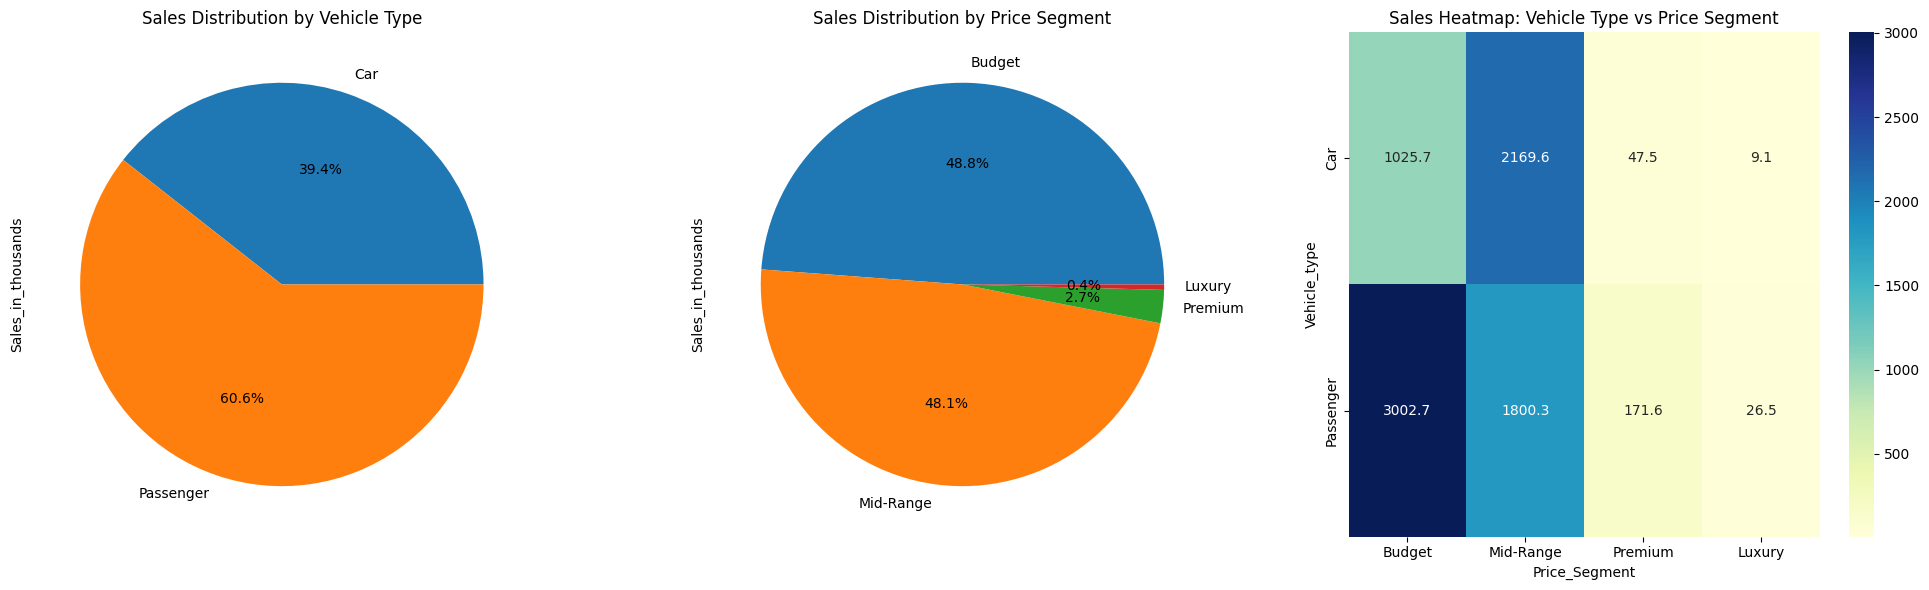

In [28]:
#Relationship Between Sales and Features
numeric_cols = data.select_dtypes(include=['number']).columns
corr_with_sales = data[numeric_cols].corr()['Sales_in_thousands'].sort_values(ascending=False)
print("Correlation between Sales and features:\n",corr_with_sales)
plt.figure(figsize=(10,6))
sns.heatmap(corr_with_sales.to_frame(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation with Sales Figures")
plt.show()

#Top/Bottom Sales Performers
# By Manufacturer
manufacturer_sales = data.groupby('Manufacturer')['Sales_in_thousands'].sum()
top_5_manufacturers = manufacturer_sales.nlargest(5)
bottom_5_manufacturers = manufacturer_sales.nsmallest(5)
print("Top 5 Manufacturers by Sales:\n", top_5_manufacturers)
print("Botton 5 Manufacturers by Sales:\n", bottom_5_manufacturers)
# By Model
model_sales = data.groupby(['Manufacturer', 'Model'])['Sales_in_thousands'].sum()
top_5_models = model_sales.nlargest(5)
bottom_5_models = model_sales.nsmallest(5)
print("Top 5 Models by Sales:\n", top_5_models)
print("Botton 5 Models by Sales:\n", bottom_5_models)

# Visualization
fig, ax = plt.subplots(2, 2, figsize=(16, 12))
top_5_manufacturers.plot(kind='bar', ax=ax[0,0], color='green')
ax[0,0].set_title('Top 5 Manufacturers by Sales')
ax[0,0].set_ylabel('Sales (thousands)')

bottom_5_manufacturers.plot(kind='bar', ax=ax[0,1], color='red')
ax[0,1].set_title('Bottom 5 Manufacturers by Sales')

top_5_models.plot(kind='bar', ax=ax[1,0], color='green')
ax[1,0].set_title('Top 5 Models by Sales')
ax[1,0].tick_params(axis='x', rotation=45)

bottom_5_models.plot(kind='bar', ax=ax[1,1], color='red')
ax[1,1].set_title('Bottom 5 Models by Sales')
ax[1,1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

#Sales Variation Across Clusters
# By Vehicle Type
vehicle_type_sales = data.groupby('Vehicle_type')['Sales_in_thousands'].sum()
print("Sales Distribution by Vehicle Type:\n",vehicle_type_sales)
# By Price Segment
price_segment_sales = data.groupby('Price_Segment')['Sales_in_thousands'].sum()
print("Sales Distribution by Price Segment:\n",price_segment_sales)
# Combined cluster analysis
cluster_sales = data.groupby(['Vehicle_type', 'Price_Segment'])['Sales_in_thousands'].sum().unstack()
print("Sales Distribution by Both:\n",cluster_sales)
# Visualization
fig, ax = plt.subplots(1, 3, figsize=(20, 6))
vehicle_type_sales.plot(kind='pie', autopct='%1.1f%%', ax=ax[0])
ax[0].set_title('Sales Distribution by Vehicle Type')

price_segment_sales.plot(kind='pie', autopct='%1.1f%%', ax=ax[1])
ax[1].set_title('Sales Distribution by Price Segment')

sns.heatmap(cluster_sales, annot=True, fmt=".1f", cmap="YlGnBu", ax=ax[2])
ax[2].set_title('Sales Heatmap: Vehicle Type vs Price Segment')
plt.tight_layout()
plt.show()

#### Insights:
1. Sales show negative correlations with resale_value, Price_in_thousands, Horsepower, and Power_perf_factor, suggests that higher-priced, higher-performance cars tend to have lower sales volumes.
2. The relationship with resale value implies that cars that depreciate less might not sell as much initially.
3. Sales have positive correlations with Wheelbase, Length, and Width, indicates that larger cars may have slightly higher sales.
4. The correlation with Fuel_capacity is weak, suggesting a possible preference for cars with larger tanks, but it's not a strong driver of sales.
5. The near-zero correlation with Engine_size and Kerb_weight suggests little to no linear relationship with sales.
6. The correlations with Engine_size, Kerb_weight, and Fuel_efficiency are very weak, suggesting that these features don't have a strong linear relationship with sales.
7. Ford, Dodge, Toyota, Honda, and Chevrolet dominate sales.
8. Porsche, Jaguar, Saab, Infiniti, and Audi have the lowest sales.
9. Ford F-Series, Ford Explorer, Toyota Camry, Ford Taurus, and Honda Accord are the top-selling models.
10. Mitsubishi 3000GT, Dodge Viper, Mercedes-Benz CL500, Oldsmobile Cutlass, and Porsche Carrera Coupe are the lowest-selling models.
11. Passenger Cars dominates in the Budget and Mid-Range segments, likely due to affordability and practicality.
12. Car-Type Vehicles have stronger in the Mid-Range, with some presence in the Budget segment. This suggests a demand for vehicles with more space and utility.
13. Premium/Luxury segment have smaller sales volumes in these segments are expected, as they cater to a more niche market.
14. **Underlying Reasons:** Several factors contribute to these sales patterns:
    1. Brand Image & Reputation: Strong brands with a positive image attract more buyers.
    2. Product Portfolio: A diverse lineup catering to different needs and budgets is essential for high sales.
    3. Pricing: Competitive pricing is crucial, especially in budget-conscious segments.
    4. Marketing & Distribution: Effective advertising and a strong dealer network drive sales.
    5. Features & Value: Customers seek a balance of desired features and perceived value for their money.
    6. Market Trends: Shifts in consumer preferences (i.e. towards SUVs or fuel-efficient cars) influence sales.
    7. External Factors: Economic conditions, fuel prices, and regulations also play a role.